# Test notebook

In [ ]:
library(ggplot2)
library(dplyr)
library(tibble)
library(msigdbr)
library(Seurat)
library(magrittr)
library("readxl")
library(purrr)
library(scales)
library(tidyr)
library(stringr)
library("ggdendro")
library(grid)
library(FactoMineR)

In [3]:
options(repr.plot.width = 18, repr.plot.height = 17, repr.plot.pointsize = 24)

chargement des données

In [4]:
my_data_d5 <- as.data.frame(read_excel("/home/adufour/work/table/epilepsie/SCPA_epilepsie.xlsx", sheet = "d5_CTRL_EPI"))
my_data_d10 <- as.data.frame(read_excel("/home/adufour/work/table/epilepsie/SCPA_epilepsie.xlsx", sheet = "d10_CTRL_EPI"))
my_data_d20 <- as.data.frame(read_excel("/home/adufour/work/table/epilepsie/SCPA_epilepsie.xlsx", sheet = "d20_CTRL_EPI"))
my_data_d40 <- as.data.frame(read_excel("/home/adufour/work/table/epilepsie/SCPA_epilepsie.xlsx", sheet = "d40_CTRL_EPI"))

In [5]:
rownames(my_data_d5) <- my_data_d5$Pathway
rownames(my_data_d10) <- my_data_d10$Pathway
rownames(my_data_d20) <- my_data_d20$Pathway
rownames(my_data_d40) <- my_data_d40$Pathway

In [6]:
my_data_d5 <- my_data_d5[,-1]
my_data_d10 <- my_data_d10[,-1]
my_data_d20 <- my_data_d20[,-1]
my_data_d40 <- my_data_d40[,-1]

In [7]:
qval_d5 <- my_data_d5[,grep("qval", colnames(my_data_d5))]
qval_d10 <- my_data_d10[,grep("qval", colnames(my_data_d10))]
qval_d20 <- my_data_d20[,grep("qval", colnames(my_data_d20))]
qval_d40 <- my_data_d40[,grep("qval", colnames(my_data_d40))]

In [8]:
colnames(qval_d5) <- gsub("_qval", "_d5", colnames(qval_d5))
colnames(qval_d10) <- gsub("_qval", "_d10", colnames(qval_d10))
colnames(qval_d20) <- gsub("_qval", "_d20", colnames(qval_d20))
colnames(qval_d40) <- gsub("_qval", "_d40", colnames(qval_d40))

In [9]:
qval_merged <- merge(qval_d5, qval_d10, by = 0)
rownames(qval_merged) <- qval_merged$Row.names
qval_merged <- qval_merged[,-1]
qval_merged <- merge(qval_merged, qval_d20, by = 0)
rownames(qval_merged) <- qval_merged$Row.names
qval_merged <- qval_merged[,-1]
qval_merged <- merge(qval_merged, qval_d40, by = 0)
rownames(qval_merged) <- qval_merged$Row.names
qval_merged <- qval_merged[,-1]

In [10]:
qval_df <- qval_merged %>%
  t() %>%
  as.data.frame() %>%
  mutate(cluster = rownames(.)) %>%
  dplyr::select(cluster, everything()) %>%
  pivot_longer(
    cols = c(2:ncol(.)),
    names_to = 'pathway'
  ) %>%
  dplyr::rename(qval = value) %>%
  mutate(id_to_merge = paste0(cluster, '_', pathway))

In [11]:
fc_d5 <- my_data_d5[,grep("FC", colnames(my_data_d5))]
fc_d10 <- my_data_d10[,grep("FC", colnames(my_data_d10))]
fc_d20 <- my_data_d20[,grep("FC", colnames(my_data_d20))]
fc_d40 <- my_data_d40[,grep("FC", colnames(my_data_d40))]

In [12]:
colnames(fc_d5) <- gsub("_FC", "_d5", colnames(fc_d5))
colnames(fc_d10) <- gsub("_FC", "_d10", colnames(fc_d10))
colnames(fc_d20) <- gsub("_FC", "_d20", colnames(fc_d20))
colnames(fc_d40) <- gsub("_FC", "_d40", colnames(fc_d40))

In [13]:
fc_merged <- merge(fc_d5, fc_d10, by = 0)
rownames(fc_merged) <- fc_merged$Row.names
fc_merged <- fc_merged[,-1]
fc_merged <- merge(fc_merged, fc_d20, by = 0)
rownames(fc_merged) <- fc_merged$Row.names
fc_merged <- fc_merged[,-1]
fc_merged <- merge(fc_merged, fc_d40, by = 0)
rownames(fc_merged) <- fc_merged$Row.names
fc_merged <- fc_merged[,-1]

In [14]:
fc_df <- fc_merged %>%
  t() %>%
  as.data.frame() %>%
  mutate(cluster = rownames(.)) %>%
  dplyr::select(cluster, everything()) %>%
  pivot_longer(
    cols = c(2:ncol(.)),
    names_to = 'pathway'
  ) %>%
  mutate(value = sign(value) * log2(abs(value) + 1e-8)) %>%
  dplyr::rename(FC = value) %>%
  mutate(id_to_merge = paste0(cluster, '_', pathway))

In [15]:
plot_df <- left_join(
    qval_df,
    fc_df %>%
    dplyr::select(id_to_merge, FC),
    by = 'id_to_merge'
  )

In [ ]:
terms_list <- c("GOBP_ADAPTIVE_IMMUNE_RESPONSE", "GOBP_AMINO_ACID_TRANSPORT", "GOBP_ANION_TRANSMEMBRANE_TRANSPORT", "GOBP_ANION_TRANSPORT", "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION", "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_II", "GOBP_ASTROCYTE_DEVELOPMENT", "GOBP_ASTROCYTE_DIFFERENTIATION", "GOBP_BLOOD_VESSEL_REMODELING", "GOBP_C4_DICARBOXYLATE_TRANSPORT", "GOBP_CARBOXYLIC_ACID_TRANSPORT", "GOBP_CHAPERONE_MEDIATED_AUTOPHAGY", "GOBP_COMPLEMENT_ACTIVATION", "GOBP_LONG_TERM_MEMORY", "GOBP_COMPLEMENT_ACTIVATION", "GOBP_EXTERNAL_ENCAPSULATING_STRUCTURE_ORGANIZATION", "GOBP_GLIAL_CELL_DEVELOPMENT", "GOBP_GLIAL_CELL_DIFFERENTIATION", "GOBP_GLIAL_CELL_PROLIFERATION", "GOBP_GLIOGENESIS", "GOBP_IMPORT_ACROSS_PLASMA_MEMBRANE", "GOBP_INTERMEDIATE_FILAMENT_BASED_PROCESS", "GOBP_INTERMEDIATE_FILAMENT_ORGANIZATION", "GOBP_LONG_TERM_SYNAPTIC_POTENTIATION", "GOBP_MACROPHAGE_ACTIVATION", "GOBP_MAINTENANCE_OF_LOCATION", "GOBP_MICROGLIAL_CELL_ACTIVATION", "GOBP_NEURON_PROJECTION_REGENERATION", "GOBP_NEUROTRANSMITTER_TRANSPORT", "GOBP_NEUROTRANSMITTER_UPTAKE", "GOBP_ORGANIC_ACID_TRANSPORT", "GOBP_POSITIVE_REGULATION_OF_GLIOGENESIS", "GOBP_POSITIVE_REGULATION_OF_NEUROGENESIS", "GOBP_POSITIVE_REGULATION_OF_SYNAPTIC_TRANSMISSION", "GOBP_REGULATION_OF_AUTOPHAGY", "GOBP_REGULATION_OF_GLIAL_CELL_PROLIFERATION", "GOBP_REGULATION_OF_GLIOGENESIS", "GOBP_REGULATION_OF_NEUROTRANSMITTER_LEVELS", "GOBP_REGULATION_OF_NEUROTRANSMITTER_TRANSPORT", "GOBP_REGULATION_OF_NEUROTRANSMITTER_UPTAKE", "GOBP_REGULATION_OF_PROTEIN_CATABOLIC_PROCESS", "GOBP_REGULATION_OF_PROTEIN_CONTAINING_COMPLEX_ASSEMBLY", "GOBP_REGULATION_OF_SYNAPTIC_PLASTICITY", "GOBP_REGULATION_OF_TISSUE_REMODELING")

In [16]:
#liste SE

In [17]:
plot_df <- plot_df[plot_df$pathway %in% terms_list,]

In [18]:
plot_df$pathway <- gsub("^GOBP_", "", plot_df$pathway)           # Retirer le préfixe
plot_df$pathway <- gsub("_", " ", plot_df$pathway)               # Remplacer _ par espace
plot_df$pathway <- tolower(plot_df$pathway)                      # Tout en minuscules
plot_df$pathway <- sub("^(.)", "\\U\\1", plot_df$pathway, perl=TRUE) # Majuscule au début

In [19]:
#liste se

In [20]:
seeds_qval_merged <- as.data.frame(scale(qval_merged))
seeds_qval_merged <- seeds_qval_merged[terms_list,]

In [21]:
seeds_fc_merged <- as.data.frame(scale(fc_merged))
seeds_fc_merged <- seeds_fc_merged[terms_list,]

In [22]:
rownames(seeds_qval_merged) <- gsub("^GOBP_", "", rownames(seeds_qval_merged))           # Retirer le préfixe
rownames(seeds_qval_merged) <- gsub("_", " ", rownames(seeds_qval_merged))               # Remplacer _ par espace
rownames(seeds_qval_merged) <- tolower(rownames(seeds_qval_merged))                      # Tout en minuscules
rownames(seeds_qval_merged) <- sub("^(.)", "\\U\\1", rownames(seeds_qval_merged), perl=TRUE) # Majuscule au début

In [23]:
rownames(seeds_fc_merged) <- gsub("^GOBP_", "", rownames(seeds_fc_merged))           # Retirer le préfixe
rownames(seeds_fc_merged) <- gsub("_", " ", rownames(seeds_fc_merged))               # Remplacer _ par espace
rownames(seeds_fc_merged) <- tolower(rownames(seeds_fc_merged))                      # Tout en minuscules
rownames(seeds_fc_merged) <- sub("^(.)", "\\U\\1", rownames(seeds_fc_merged), perl=TRUE) # Majuscule au début

In [24]:
dist_mat <- dist(seeds_qval_merged * seeds_fc_merged, method = 'euclidean')
hclust_avg <- hclust(dist_mat, method = 'ward.D')
dend <- as.dendrogram(hclust_avg)
dend_data <- dendro_data(dend, type = "rectangle")

In [25]:
dendro_plot <- ggplot(dend_data$segments) + 
  geom_segment(aes(x = x, y = y, xend = xend, yend = yend)) +
  theme_void() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    legend.text = element_blank(),
    legend.title = element_blank(),
    axis.title.y = element_blank(),
    axis.text.y = element_blank()
  )

In [26]:
labels <- c("0.0", "0.1", "0.2", "0.3", "1", "2", "3.0", "3.1", "3.2", "3.3", "4")
days <- c("d5", "d10", "d20", "d40")
ordered_vector <- as.vector(outer(labels, days, function(x, y) paste0(x, "_", y)))

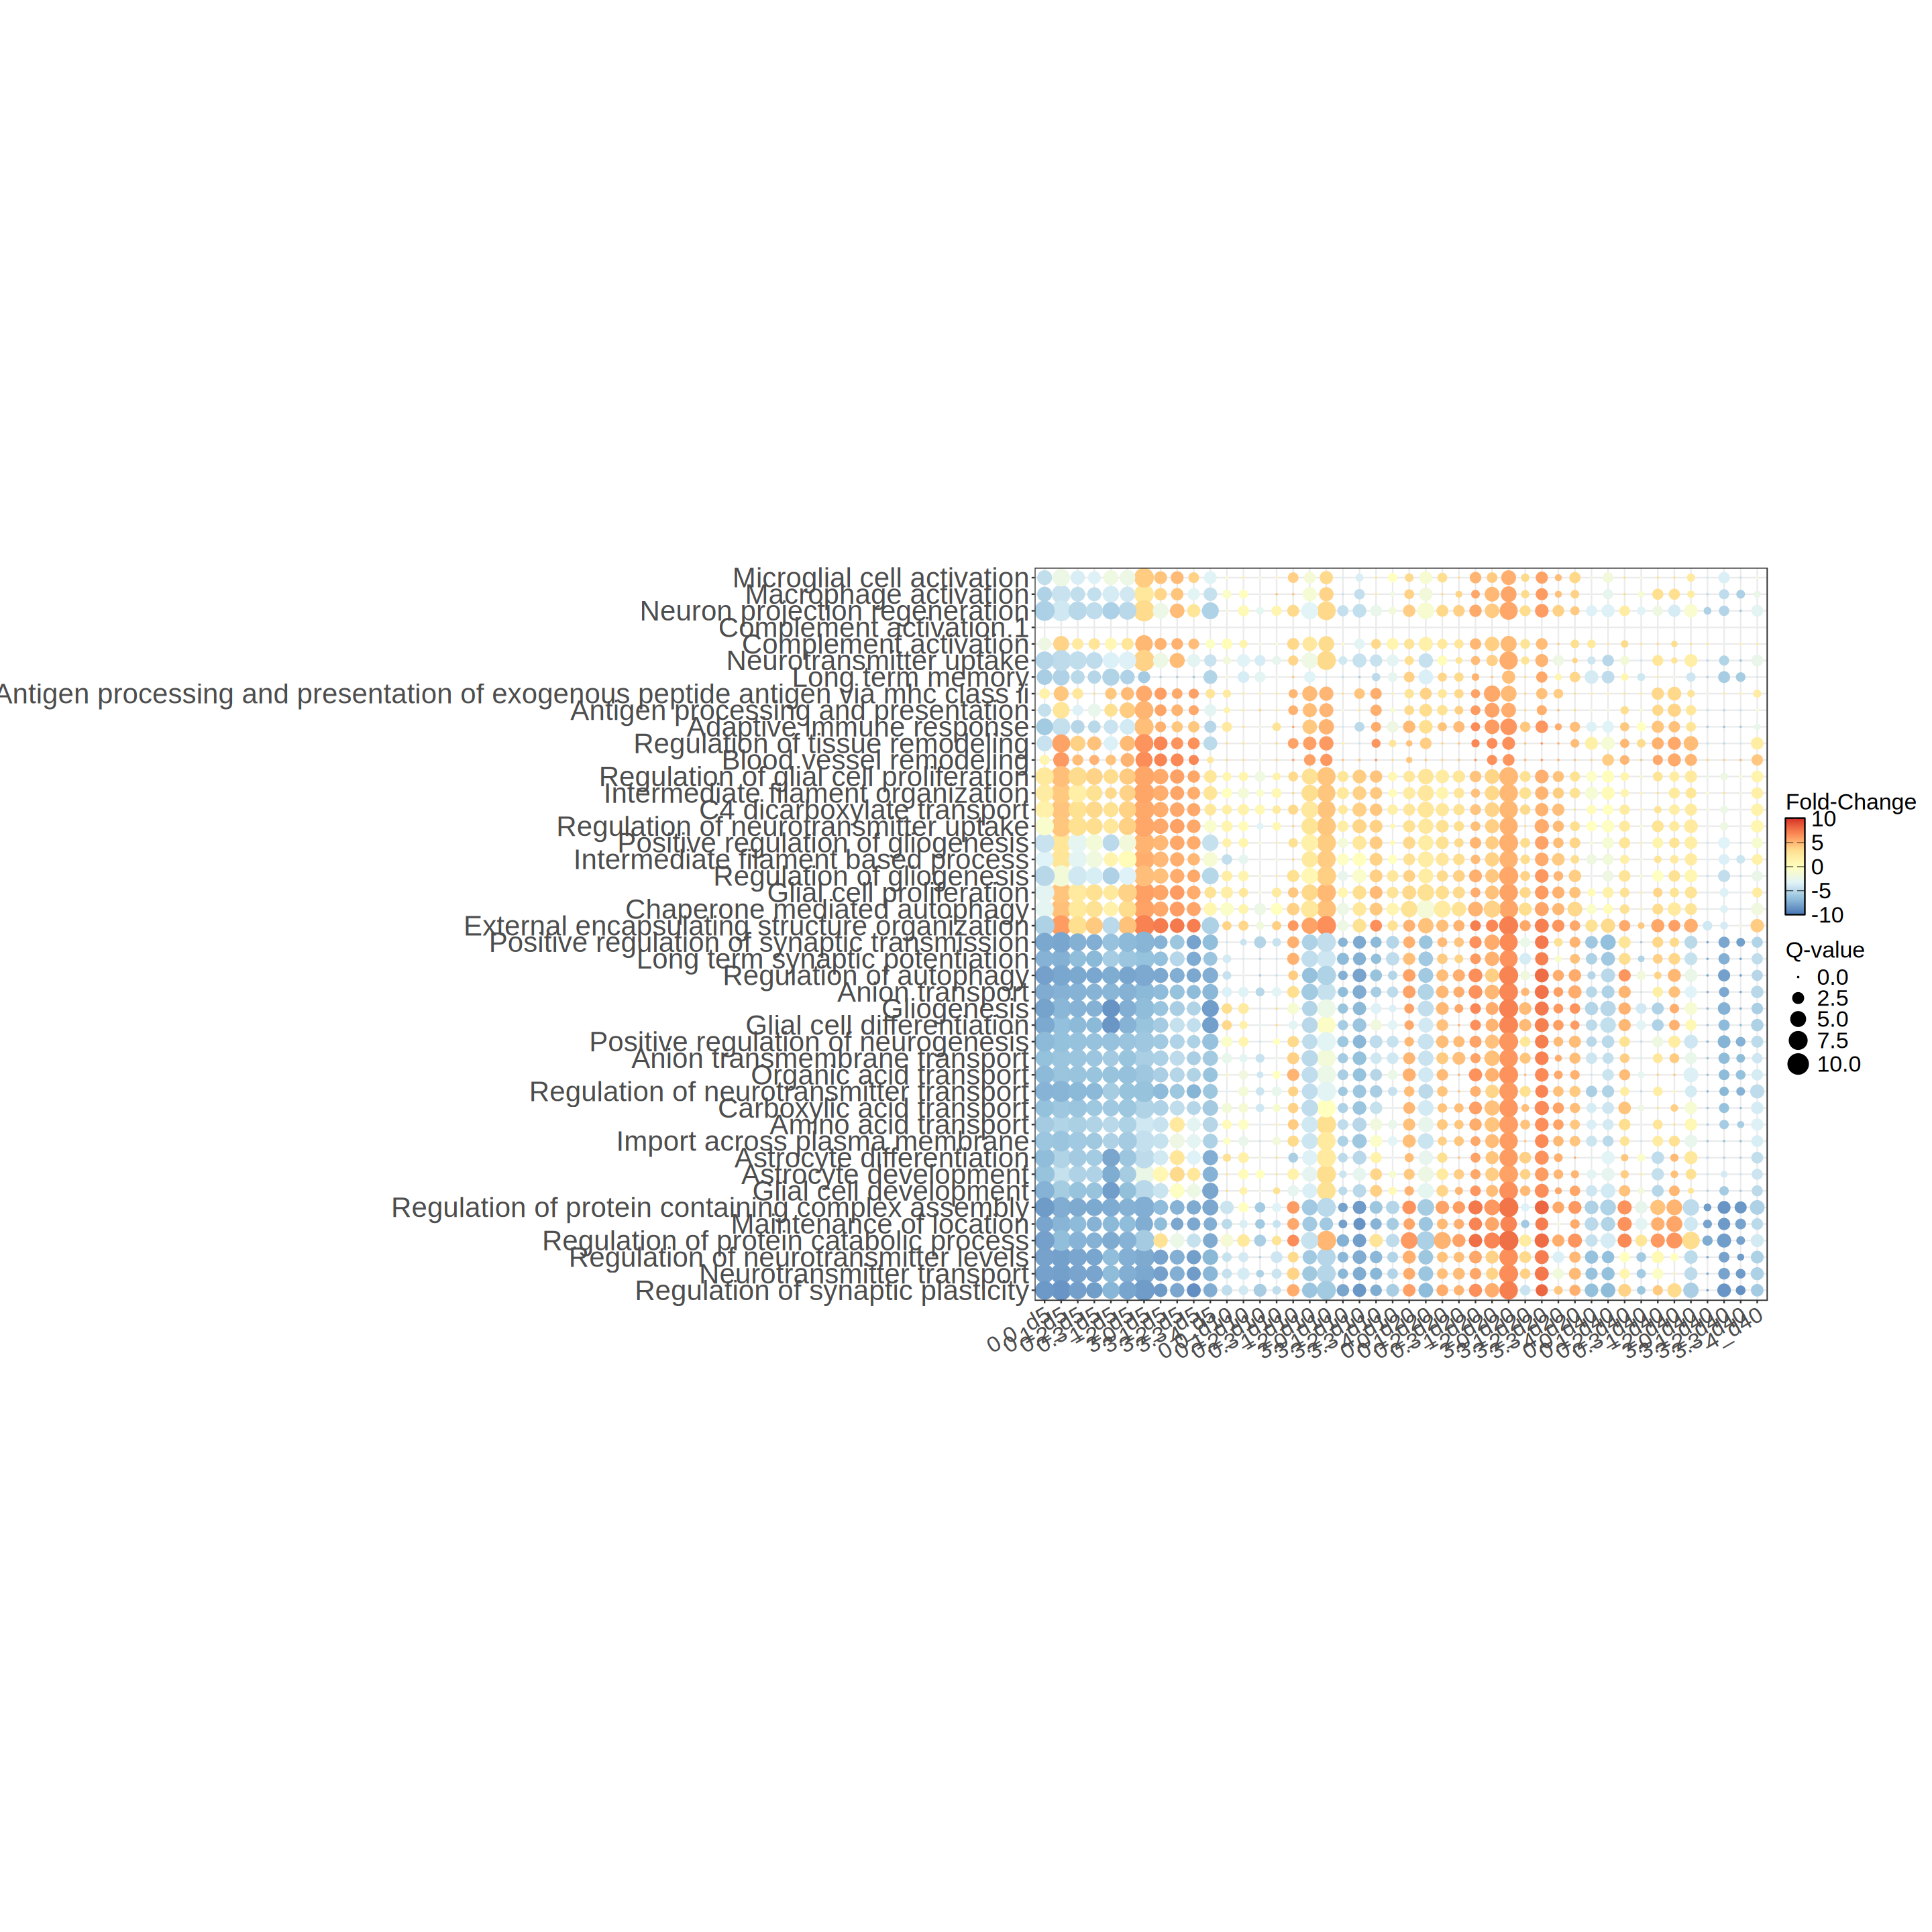

In [27]:
plot <- plot_df %>%
  ggplot(aes(cluster, pathway)) +
  geom_point(aes(color = FC, size = qval)) +
  scale_color_distiller(
    palette = 'RdYlBu',
    direction = -1,
    name = 'Fold-Change',
    limits = c(-10, 10),
    guide = guide_colorbar(frame.colour = "black", ticks.colour = "black")
  ) +
  scale_y_discrete(limits=dend_data$labels$label) +
  scale_x_discrete(limits=ordered_vector) +
  scale_size(name = 'Q-value',
             #limits = c(0, 10),
             range = c(0, 8)
            ) +
  #labs(y = 'Cluster', color = 'Expression') +
  coord_fixed() +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 30, hjust = 1, size = 20),
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 20),
    axis.title.y = element_blank(),
    axis.text.y = element_text(size = 25)
  )
options(repr.plot.width = 24, repr.plot.height = 24, repr.plot.pointsize = 24)
plot

In [28]:
pdf(file = '/home/adufour/work/plots/epilepsie/SCPA_dotplot_SE_CTRL_all_terms.pdf',   # The directory you want to save the file in
    width = 32, # The width of the plot in inches
    height = 35) # The height of the plot in inches

plot
# Step 3: Run dev.off() to create the file!
dev.off()

pdf 
  2

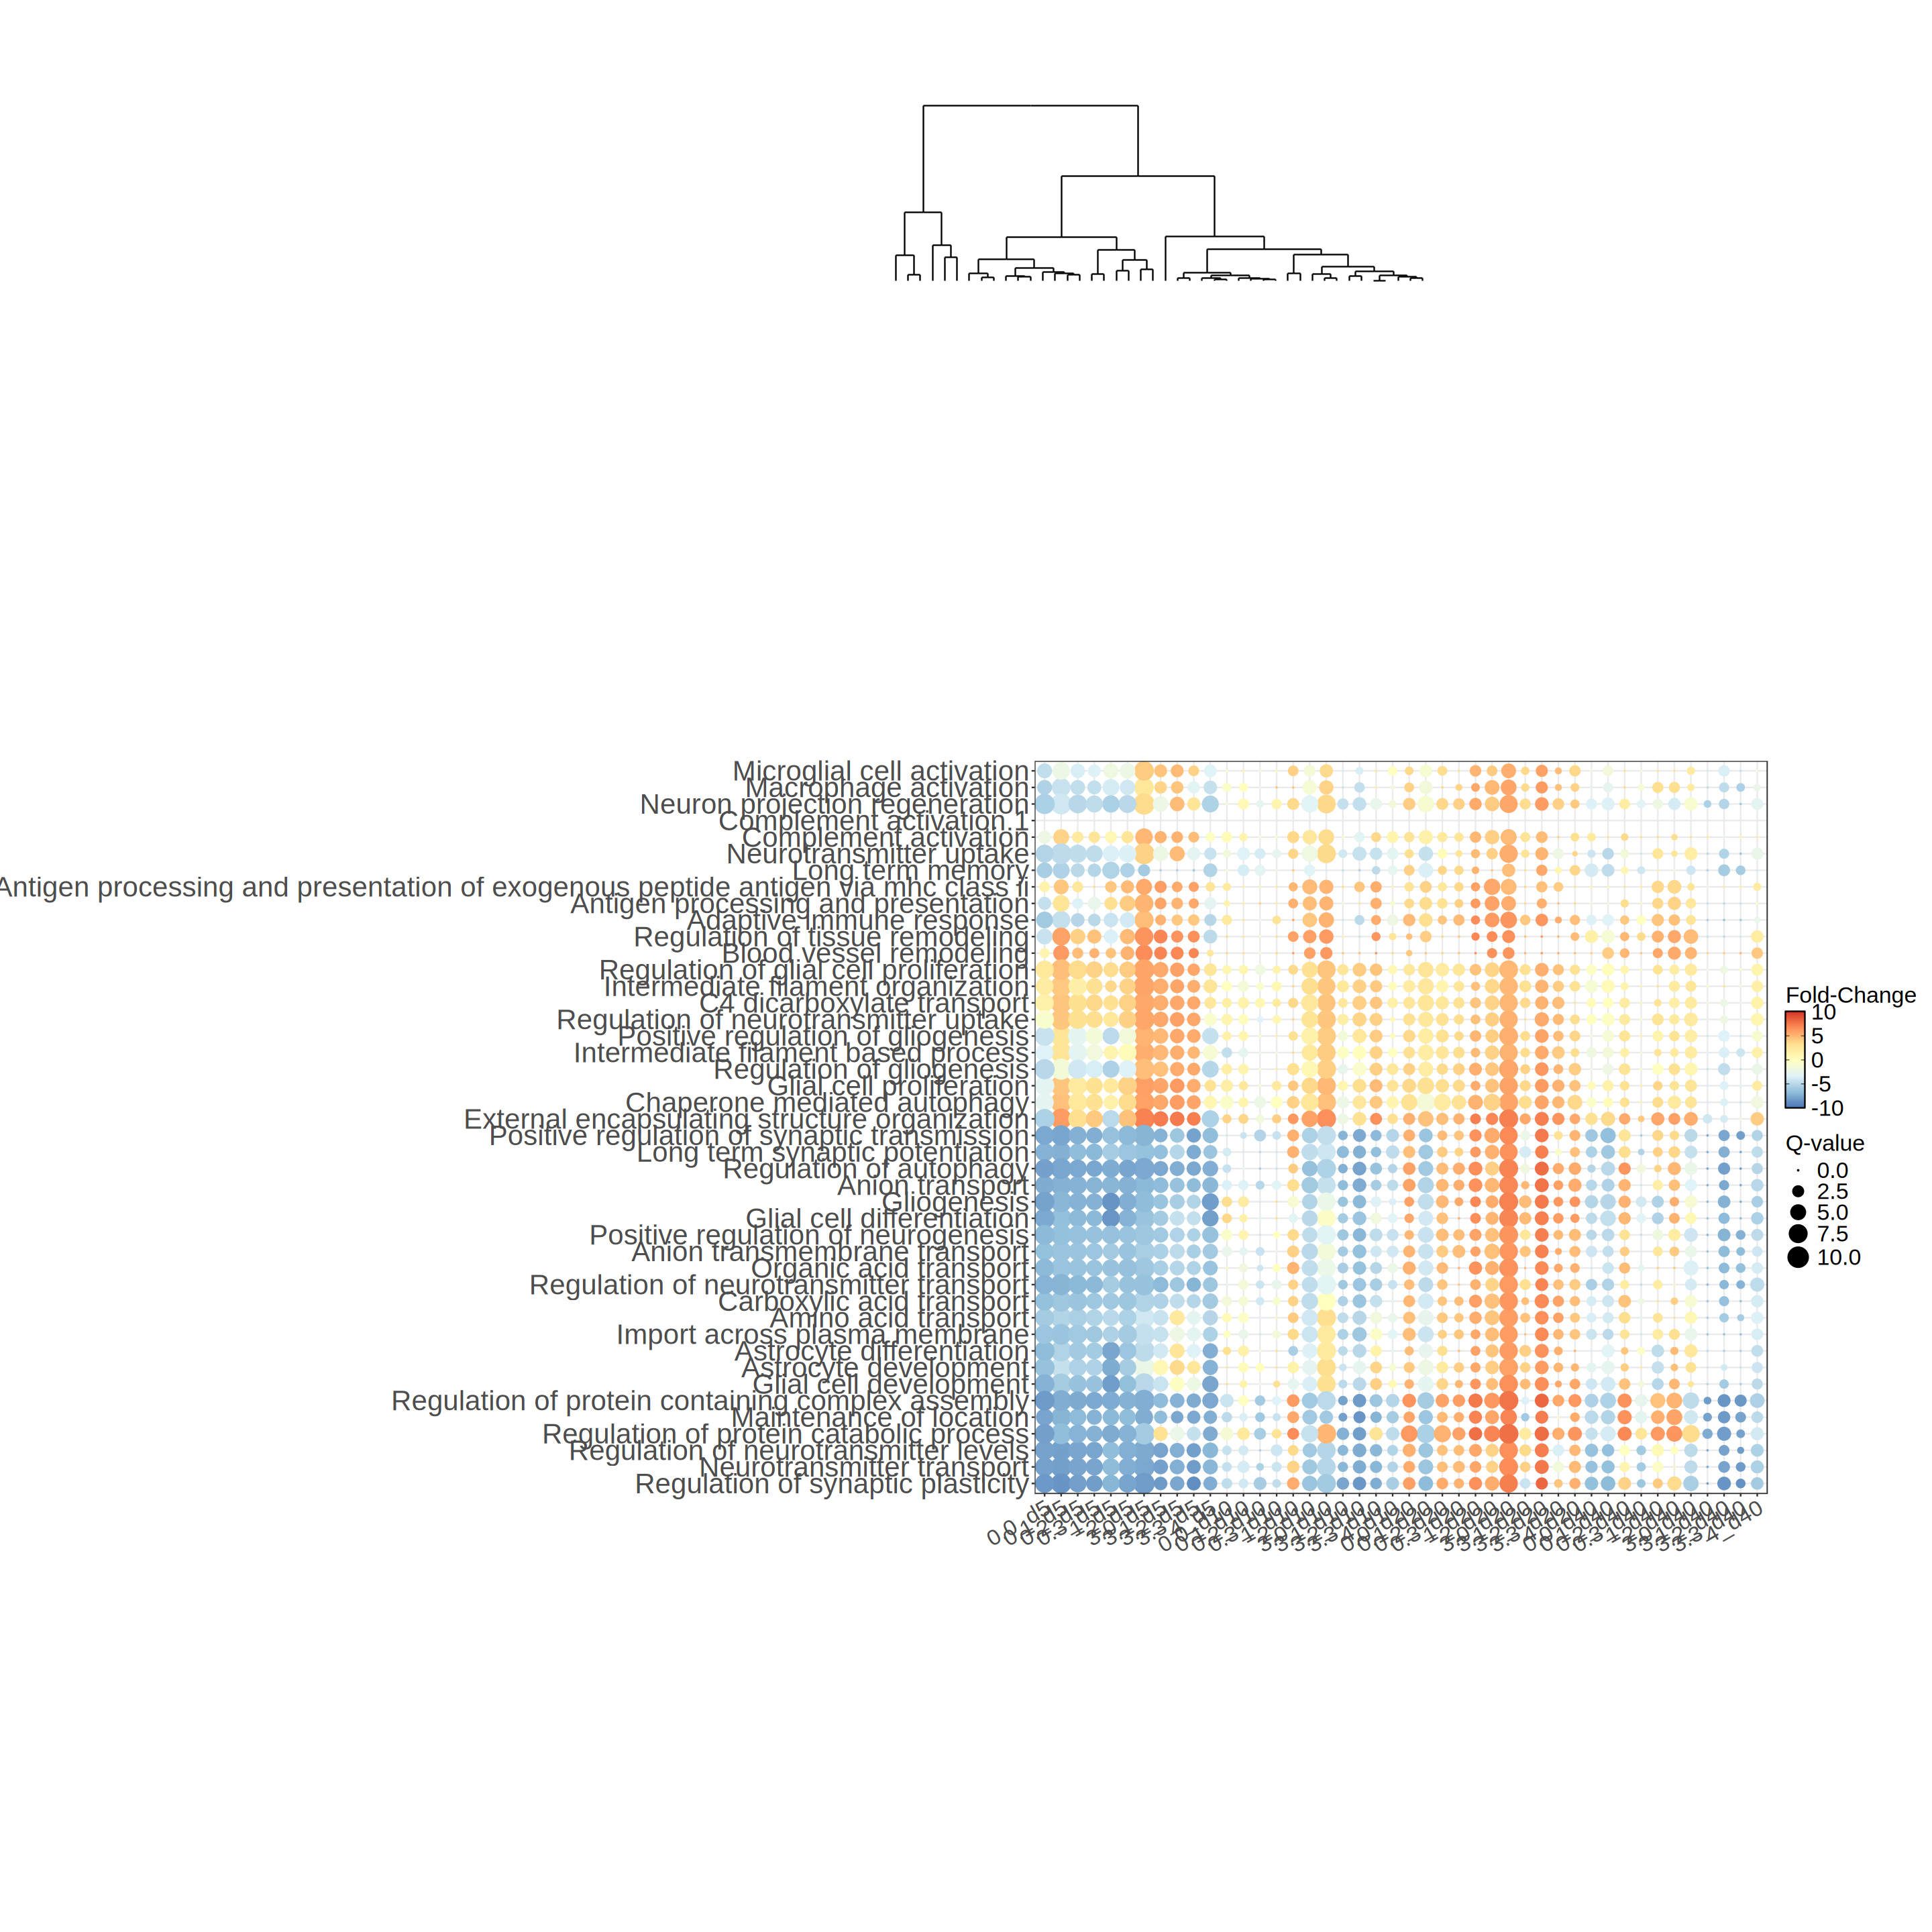

In [28]:
grid.newpage()
print(plot, vp=viewport(width = 1, height=0.6, x=0.5, y=0.4))
print(dendro_plot, vp=viewport(width=0.3, height=0.1, x=0.6, y=0.9))

In [29]:
pdf(file = '/home/adufour/work/plots/epilepsie/SCPA_dotplot_SE_vs_CONTROL.pdf',   # The directory you want to save the file in
    width = 35, # The width of the plot in inches
    height = 35) # The height of the plot in inches

grid.newpage()
print(plot, vp=viewport(width = 1, height=0.6, x=0.5, y=0.4))
print(dendro_plot, vp=viewport(width=0.3, height=0.1, x=0.6, y=0.9))

# Step 3: Run dev.off() to create the file!
dev.off()

pdf 
  2